In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

train_equity = pd.read_csv("../data/split_train_equity.csv", index_col=0, parse_dates=True).squeeze()
test_equity = pd.read_csv("../data/split_test_equity.csv", index_col=0, parse_dates=True).squeeze()
train_trades = pd.read_csv("../data/split_train_trades.csv", parse_dates=["timestamp"])
test_trades = pd.read_csv("../data/split_test_trades.csv", parse_dates=["timestamp"])

print(f"Train equity points: {len(train_equity)}, trades: {len(train_trades)}")
print(f"Test equity points:  {len(test_equity)}, trades: {len(test_trades)}")
print(f"Train range: {train_equity.index.min().date()} to {train_equity.index.max().date()}")
print(f"Test range:  {test_equity.index.min().date()} to {test_equity.index.max().date()}")

Train equity points: 806, trades: 29
Test equity points:  398, trades: 13
Train range: 2020-03-19 to 2023-05-31
Test range:  2023-06-01 to 2024-12-30


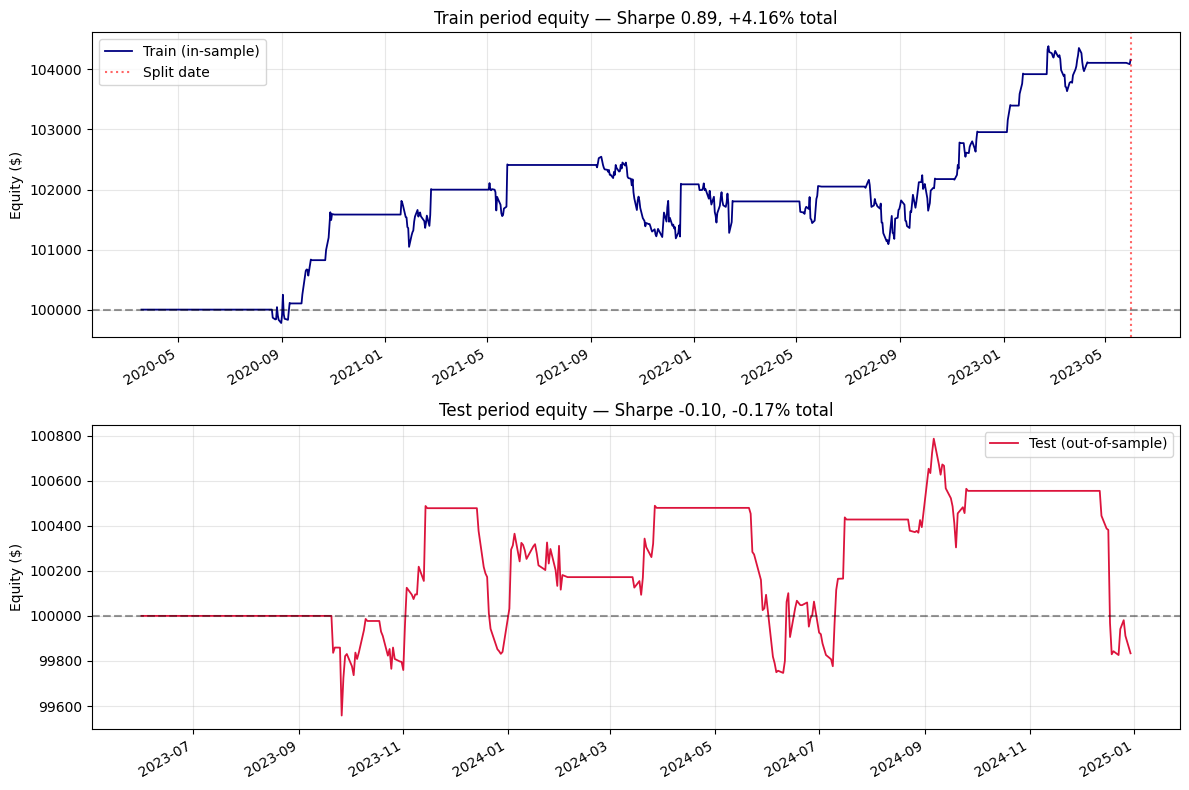

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

train_equity.plot(ax=axes[0], color="navy", linewidth=1.3, label="Train (in-sample)")
axes[0].axhline(100_000, color="black", linestyle="--", alpha=0.4)
axes[0].axvline(pd.Timestamp("2023-06-01"), color="red", linestyle=":", alpha=0.6, label="Split date")
axes[0].set_title("Train period equity — Sharpe 0.89, +4.16% total")
axes[0].set_ylabel("Equity ($)")
axes[0].legend()
axes[0].grid(alpha=0.3)

test_equity.plot(ax=axes[1], color="crimson", linewidth=1.3, label="Test (out-of-sample)")
axes[1].axhline(100_000, color="black", linestyle="--", alpha=0.4)
axes[1].set_title("Test period equity — Sharpe -0.10, -0.17% total")
axes[1].set_ylabel("Equity ($)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

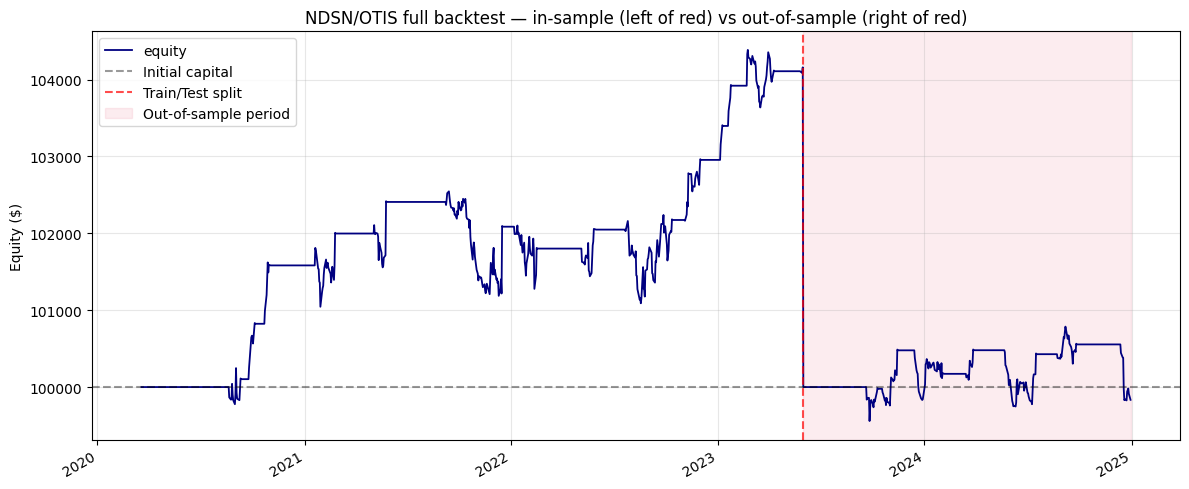

In [3]:
combined = pd.concat([train_equity, test_equity])

fig, ax = plt.subplots(figsize=(12, 5))
combined.plot(ax=ax, color="navy", linewidth=1.3)
ax.axhline(100_000, color="black", linestyle="--", alpha=0.4, label="Initial capital")
ax.axvline(pd.Timestamp("2023-06-01"), color="red", linestyle="--", alpha=0.7, label="Train/Test split")

# Shade the test period
test_start = test_equity.index.min()
test_end = test_equity.index.max()
ax.axvspan(test_start, test_end, color="crimson", alpha=0.08, label="Out-of-sample period")

ax.set_title("NDSN/OTIS full backtest — in-sample (left of red) vs out-of-sample (right of red)")
ax.set_ylabel("Equity ($)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()